# BC reconstruction method sensitivity (input-data uncertainty)

Most of the Ahr's discharge gauges were destroyed in the 2021 flood, so the hydrographs for the 3
ungauged tributary locations (`new1`, `Niederadenau`, `new2`) had to be reconstructed indirectly
(water marks, auxiliary models) rather than measured. The 4 gauged locations (`Kreuzberg`, `Denn`,
`Kirmutscheid`, `Muesch`) are identical across all three SFINCS runs compared here — only the 3
reconstructed tributaries differ:

- `original` — the hydrograph used everywhere else in this repo
- `method1` — alternative reconstruction of the 3 ungauged tributaries
- `method2` — a second alternative reconstruction

All three are now warmstarted with their own matching spinup (method1/2 were re-run for this after
an earlier cold-start mismatch was caught), so this is a clean comparison: same model, same gauged
inflows, only the reconstructed-tributary hydrographs differ. The spread across the three is a direct
estimate of how much of the model's predictive uncertainty comes from *not knowing* the true
discharge at the ungauged tributaries — as opposed to model error itself.

Uses the same `best_sweep_multisim_multiscale_loss` (`best_valloss`, 4-scale mesh) checkpoint as
`visualize_finetuned_fixed_gt_multisim_multiscale_loss.ipynb`, evaluated on each method's own SFINCS
ground truth (not a synthetic BC-scaling probe — these are 3 real, independent simulations).

In [11]:
import sys, os

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from itertools import combinations

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Datasets and checkpoint

In [12]:
CONFIG     = 'config_best_sweep.yaml'   # architecture auto-detected from checkpoint; 4-scale mesh
CHECKPOINT = os.path.join(REPO_ROOT, 'results', 'best_sweep_multisim_multiscale_loss.h5')  # best_valloss

DATASETS = {
    'original': 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart',
    'method1':  'ahr_river_v03_marg_method1_additionalsrc_velocity_100m_warmstart',
    'method2':  'ahr_river_v03_marg_method2_additionalsrc_velocity_100m_warmstart',
}

exists = os.path.exists(CHECKPOINT)
print(f"checkpoint exists={exists!s:<6}  {CHECKPOINT}")
for name, ds in DATASETS.items():
    p = f'database/datasets/test/{ds}.pkl'
    print(f"{name:<10} {ds:<52} exists={os.path.exists(p)}")

checkpoint exists=True    c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multisim_multiscale_loss.h5
original   ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart exists=True
method1    ahr_river_v03_marg_method1_additionalsrc_velocity_100m_warmstart exists=True
method2    ahr_river_v03_marg_method2_additionalsrc_velocity_100m_warmstart exists=True


## Build each dataset and run the (shared) model

Same model loaded once (architecture is identical across the three — same template mesh, same
config), then evaluated independently on each method's own test dataset and its own ground truth.

In [13]:
device = torch.device('cpu')

def load_model_from_checkpoint(checkpoint_path, config, num_node_features, num_edge_features,
                                temporal_test_dataset_parameters, num_scales):
    model_parameters = dict(config.models)
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = num_scales

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd   = ckpt['state_dict']
    hid  = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]
    model_parameters['hid_features'] = hid
    model_parameters['K']            = K_list

    model = get_model(model_type)(
        num_node_features=num_node_features, num_edge_features=num_edge_features,
        previous_t=temporal_test_dataset_parameters['previous_t'], device=device,
        **model_parameters
    ).to(device)

    plmodule_kwargs = {
        'model': model, 'lr_info': config['lr_info'], 'trainer_options': config.trainer_options,
        'temporal_test_dataset_parameters': temporal_test_dataset_parameters
    }
    plmodule = LightningTrainer.load_from_checkpoint(checkpoint_path, map_location=device, **plmodule_kwargs)
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list


results = {}
model = None
for name, dataset_name in DATASETS.items():
    print(f'--- {name} ({dataset_name}) ---')
    cfg = read_config(CONFIG)
    cfg['dataset_parameters']['test_dataset_name']  = dataset_name
    cfg['dataset_parameters']['train_dataset_name'] = dataset_name
    wandb.init(mode='disabled', project='mswe-gnn', config=cfg, reinit=True)
    fix_dict_in_config(wandb)
    config = wandb.config

    _, _, test_dataset, scalers = create_model_dataset(
        scalers=config.scalers, device=device,
        **config.dataset_parameters, **config.selected_node_features, **config.selected_edge_features)
    ttdp = get_temporal_test_dataset_parameters(config, config.temporal_dataset_parameters)
    temporal_test_dataset = to_temporal_dataset(test_dataset, rollout_steps=-1, **ttdp)
    num_node_features = temporal_test_dataset[0].x.size(-1)
    num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

    if model is None:
        model, hid, K_list = load_model_from_checkpoint(
            CHECKPOINT, config, num_node_features, num_edge_features, ttdp, test_dataset[0].mesh.num_meshes)
        print(f'Loaded model: hid={hid} K={K_list}')

    plot_rollout = PlotRollout(model, test_dataset[0], scalers=scalers, warmup_steps=0, **ttdp)
    rl = plot_rollout._get_rollout_loss(type_loss='RMSE').mean(0)
    rmse_wd = rl[0].item() if rl.ndim > 0 else rl.item()
    csi005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
    csi03  = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()

    results[name] = dict(plot_rollout=plot_rollout, rmse_wd=rmse_wd, csi_005=csi005, csi_03=csi03,
                          n_steps=plot_rollout.real_rollout.shape[-1])
    print(f'  RMSE_WD={rmse_wd:.4f}  CSI@0.05={csi005:.4f}  CSI@0.30={csi03:.4f}  '
          f'n_steps={results[name]["n_steps"]}')

--- original (ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart) ---
The validation dataset you are using is the training one. Careful!
Loaded model: hid=32 K=[1, 1, 1, 5, 4, 3, 2]
  RMSE_WD=0.1304  CSI@0.05=0.7991  CSI@0.30=0.8518  n_steps=118
--- method1 (ahr_river_v03_marg_method1_additionalsrc_velocity_100m_warmstart) ---
The validation dataset you are using is the training one. Careful!
  RMSE_WD=0.1532  CSI@0.05=0.7922  CSI@0.30=0.8428  n_steps=120
--- method2 (ahr_river_v03_marg_method2_additionalsrc_velocity_100m_warmstart) ---
The validation dataset you are using is the training one. Careful!
  RMSE_WD=0.1468  CSI@0.05=0.7841  CSI@0.30=0.8374  n_steps=120


## Reconstruction-method uncertainty estimate

The spread (mean +- std, range) across the 3 methods is the actual answer to "how much does not
knowing the true ungauged-tributary discharge affect the model's flood prediction."

In [14]:
header = f"{'method':<10} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}"
print(header)
print('-' * len(header))
for name, r in results.items():
    print(f"{name:<10} {r['rmse_wd']:>9.4f} {r['csi_005']:>9.4f} {r['csi_03']:>9.4f}")

rmse_vals   = np.array([r['rmse_wd'] for r in results.values()])
csi005_vals = np.array([r['csi_005'] for r in results.values()])
csi03_vals  = np.array([r['csi_03']  for r in results.values()])

print(f"\nSpread across reconstruction methods (n={len(results)}):")
print(f"  RMSE_WD : mean={rmse_vals.mean():.4f} +- {rmse_vals.std(ddof=1):.4f}   "
      f"range [{rmse_vals.min():.4f}, {rmse_vals.max():.4f}]")
print(f"  CSI_005 : mean={csi005_vals.mean():.4f} +- {csi005_vals.std(ddof=1):.4f}   "
      f"range [{csi005_vals.min():.4f}, {csi005_vals.max():.4f}]")
print(f"  CSI_03  : mean={csi03_vals.mean():.4f} +- {csi03_vals.std(ddof=1):.4f}   "
      f"range [{csi03_vals.min():.4f}, {csi03_vals.max():.4f}]")

# Context: compare against the seed-uncertainty ruler (results/seed_table.csv), which captures
# training-randomness spread on a single fixed hydrograph. If the reconstruction-method spread is
# comparable to or larger than the seed ruler's spread, input-data uncertainty is at least as
# important a source of error as training variance.
try:
    import pandas as pd
    seed_table = pd.read_csv('results/seed_table.csv')
    ruler = seed_table[seed_table.ckpt == 'best_CSI']
    print(f"\nFor context, seed ruler (n={len(ruler)}, training-randomness only, single hydrograph):")
    print(f"  CSI_005 : mean={ruler.CSI_005.mean():.4f} +- {ruler.CSI_005.std(ddof=1):.4f}   "
          f"range [{ruler.CSI_005.min():.4f}, {ruler.CSI_005.max():.4f}]")
except FileNotFoundError:
    print('\n(results/seed_table.csv not found locally - skipping seed-ruler context)')

method       RMSE_WD  CSI@0.05  CSI@0.30
----------------------------------------
original      0.1304    0.7991    0.8518
method1       0.1532    0.7922    0.8428
method2       0.1468    0.7841    0.8374

Spread across reconstruction methods (n=3):
  RMSE_WD : mean=0.1435 +- 0.0118   range [0.1304, 0.1532]
  CSI_005 : mean=0.7918 +- 0.0075   range [0.7841, 0.7991]
  CSI_03  : mean=0.8440 +- 0.0073   range [0.8374, 0.8518]

For context, seed ruler (n=5, training-randomness only, single hydrograph):
  CSI_005 : mean=0.7609 +- 0.0419   range [0.7116, 0.8111]


## Does the model amplify or dampen the input uncertainty?

For each pair of methods, compare the RMSE between their two *ground truths* (how different the real
floods actually are) against the RMSE between their two *predictions* (how different the model says
they are). If pred-RMSE >> truth-RMSE, the model amplifies the input discrepancy; if pred-RMSE <<
truth-RMSE, the model smooths over it. Cropped to the shorter of each pair's rollout length (119 vs
121 steps).

In [15]:
def rmse_between(a, b):
    T = min(a.shape[-1], b.shape[-1])
    return float(torch.sqrt(((a[..., :T] - b[..., :T]) ** 2).mean()))

header = f"{'pair':<22} {'truth-vs-truth RMSE':>20} {'pred-vs-pred RMSE':>18} {'ratio (pred/truth)':>19}"
print(header)
print('-' * len(header))
for n1, n2 in combinations(DATASETS.keys(), 2):
    r1, r2 = results[n1], results[n2]
    truth_rmse = rmse_between(r1['plot_rollout']._real_rollout_s0[:, 0, :], r2['plot_rollout']._real_rollout_s0[:, 0, :])
    pred_rmse  = rmse_between(r1['plot_rollout']._predicted_rollout_s0[:, 0, :], r2['plot_rollout']._predicted_rollout_s0[:, 0, :])
    ratio = pred_rmse / truth_rmse if truth_rmse else float('nan')
    print(f"{n1} vs {n2:<15} {truth_rmse:>20.4f} {pred_rmse:>18.4f} {ratio:>19.2f}")

pair                    truth-vs-truth RMSE  pred-vs-pred RMSE  ratio (pred/truth)
----------------------------------------------------------------------------------
original vs method1                       0.0837             0.0816                0.98
original vs method2                       0.0504             0.0898                1.78
method1 vs method2                       0.0516             0.0847                1.64


## Flood maps per method
Same style as the rest of this notebook family — `compare_h_rollout` at matched hours.

--- original ---


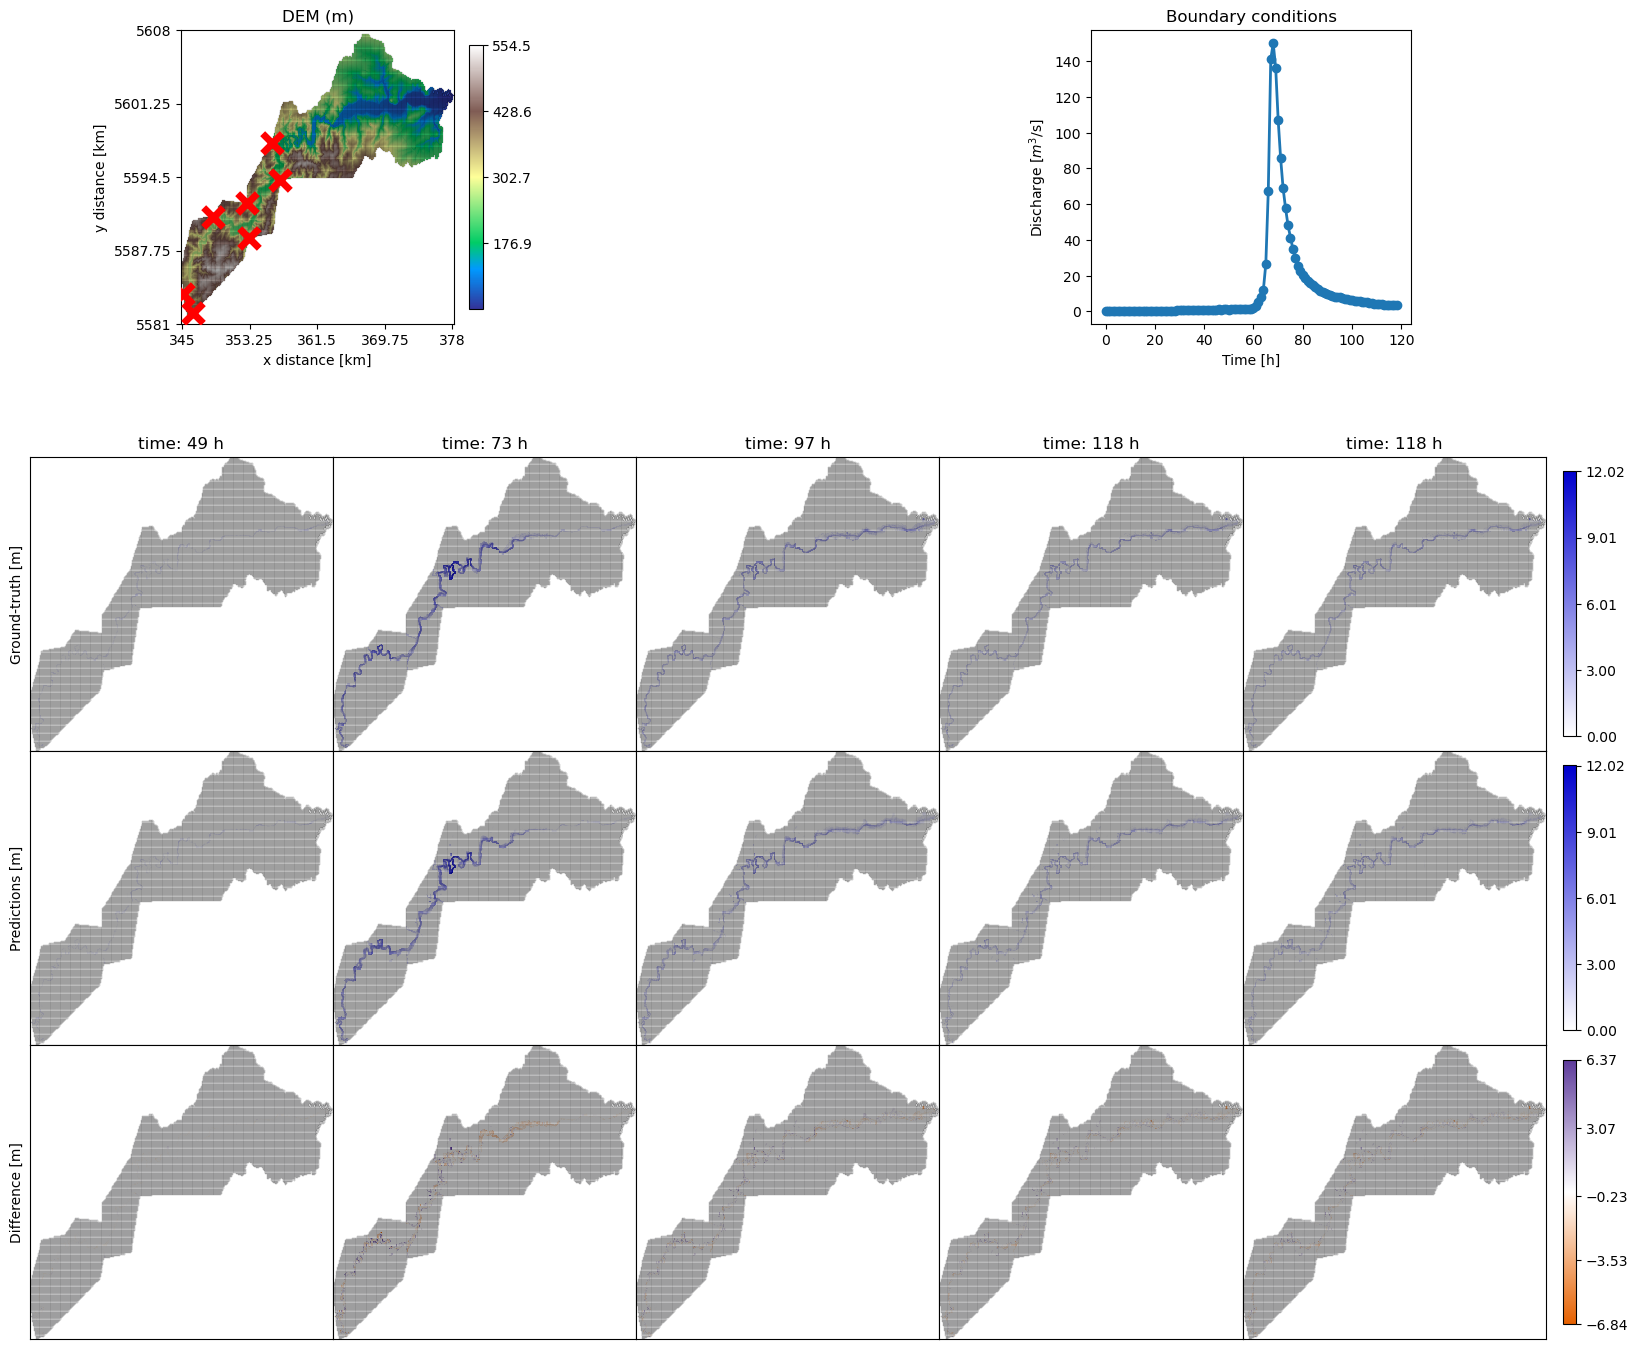

--- method1 ---


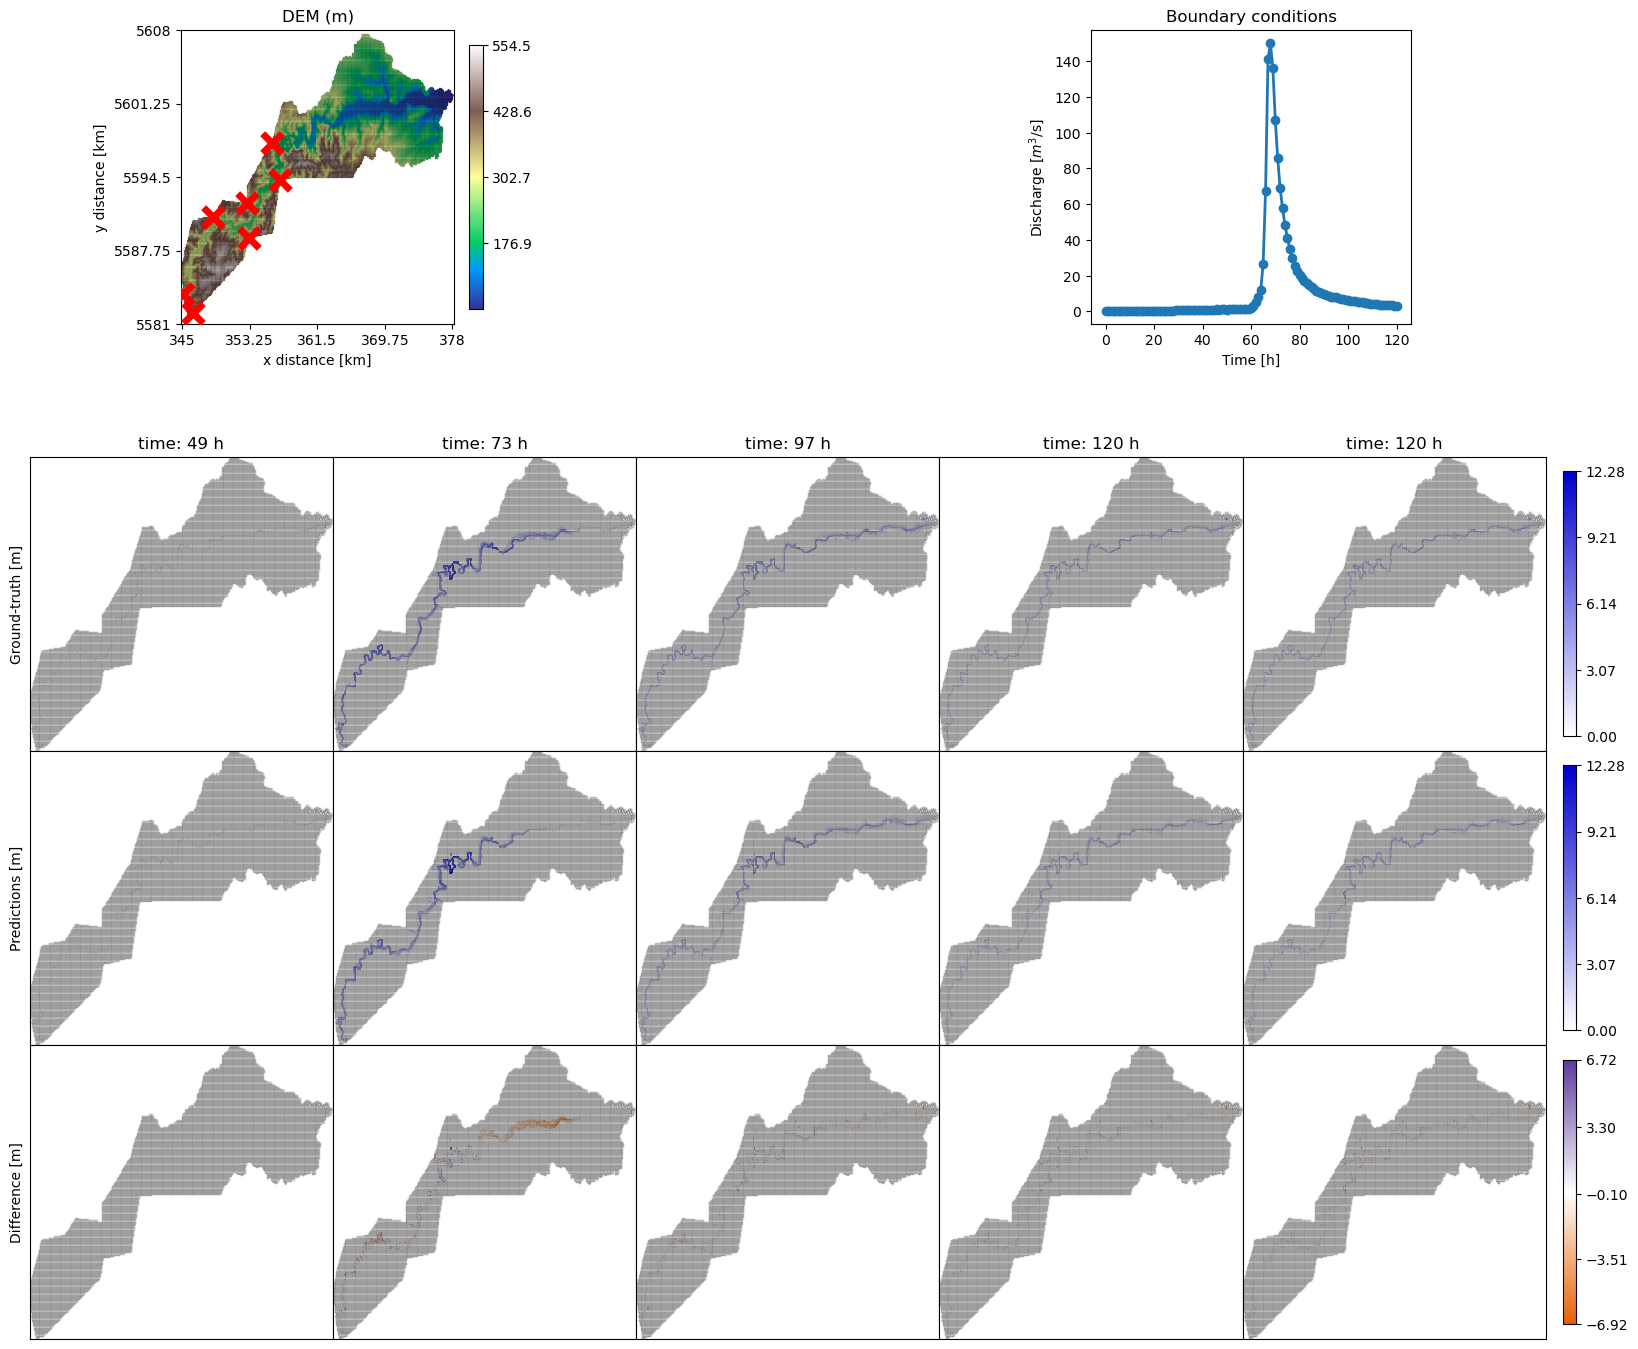

--- method2 ---


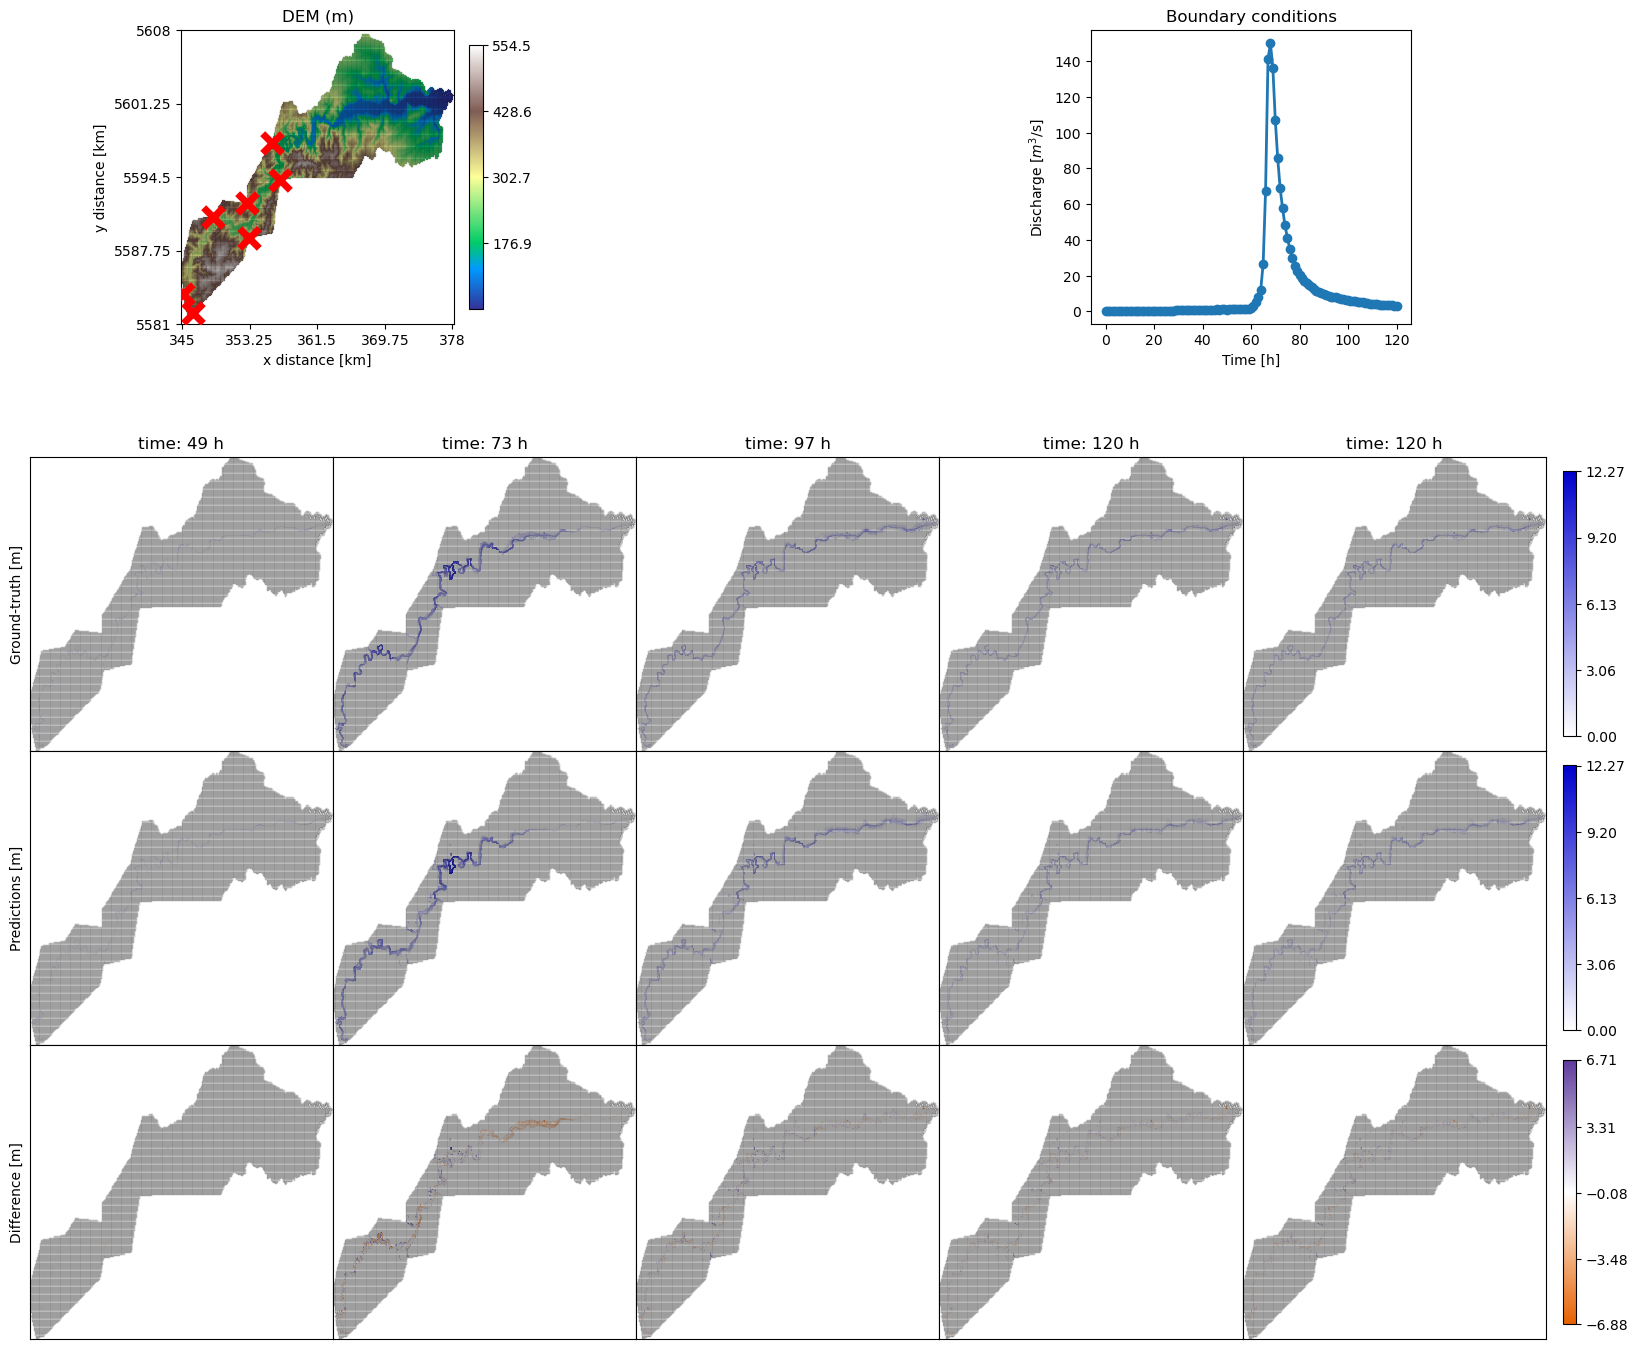

In [16]:
for name, r in results.items():
    print(f'--- {name} ---')
    pr = r['plot_rollout']
    n_steps = pr.real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    pr.compare_h_rollout(plot_times=plot_times, scale=0)
    plt.show()

### Spatial difference between predictions
Where does the choice of reconstruction method actually change the flood, at a shared reference
time (t=96h, within all three rollout lengths)? Should cluster near the `new1`/`Niederadenau`/`new2`
confluences if the model is behaving sensibly — a catchment-wide difference would be a red flag.

The validation dataset you are using is the training one. Careful!


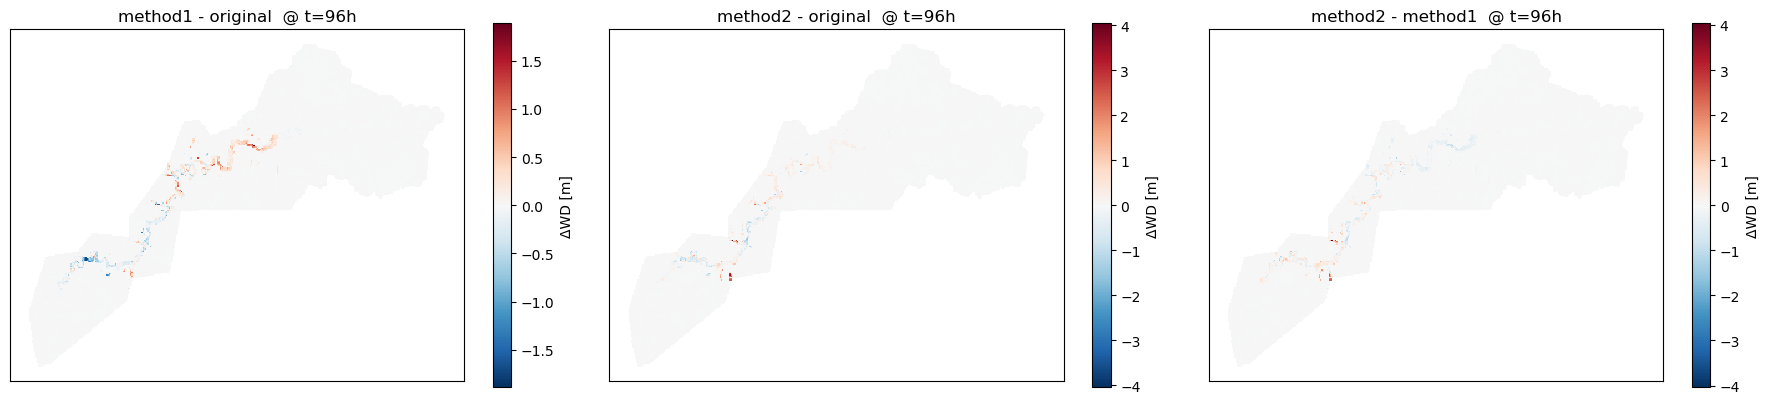

In [17]:
T_REF = 96
wd_by_method = {name: r['plot_rollout']._predicted_rollout_s0[:, 0, T_REF].cpu().numpy()
                for name, r in results.items()}

# mesh coordinates: any dataset works, same template for all three
cfg0 = read_config(CONFIG)
cfg0['dataset_parameters']['test_dataset_name']  = DATASETS['original']
cfg0['dataset_parameters']['train_dataset_name'] = DATASETS['original']
wandb.init(mode='disabled', project='mswe-gnn', config=cfg0, reinit=True)
fix_dict_in_config(wandb)
config0 = wandb.config
_, _, test_dataset0, _ = create_model_dataset(
    scalers=config0.scalers, device=device,
    **config0.dataset_parameters, **config0.selected_node_features, **config0.selected_edge_features)
n_s0 = wd_by_method['original'].shape[0]
pos_s0 = np.asarray(test_dataset0[0].mesh.face_xy)[:n_s0]

pairs = list(combinations(DATASETS.keys(), 2))
fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5.5))
if len(pairs) == 1:
    axes = [axes]
for ax, (n1, n2) in zip(axes, pairs):
    diff = wd_by_method[n2] - wd_by_method[n1]
    vmax = max(abs(diff.min()), abs(diff.max()), 1e-3)
    sc = ax.scatter(pos_s0[:, 0], pos_s0[:, 1], c=diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=4, marker='s', linewidths=0)
    ax.set_title(f'{n2} - {n1}  @ t={T_REF}h')
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, shrink=0.7, label='ΔWD [m]')
plt.tight_layout()
plt.show()

## Reading the results

- The **spread across methods** (RMSE_WD / CSI mean +- std) is the direct estimate of how much
  prediction uncertainty comes from not knowing the true ungauged-tributary discharge — compare it
  to the seed-ruler spread (training-randomness only) to see which source of uncertainty dominates.
- The **pred/truth RMSE ratio**: close to 1 means the model faithfully propagates input uncertainty;
  much greater than 1 means the model amplifies small input differences into large prediction
  differences (concerning — implies sensitivity to noise in the discharge reconstruction); much less
  than 1 means the model smooths over real differences in the flood (may be under-responsive to the
  tributaries, consistent with earlier BC-sensitivity findings).
- The **spatial diff maps** should show most of the disagreement concentrated near the 3 reconstructed
  tributaries' confluences — if it's spread across the whole catchment instead, that points to the
  same signal-leakage concern raised in `visualize_bc_nonuniform_sensitivity.ipynb`.